# This file makes correlation plots for different variables

author: Eike E. Köhn ......
date: July 29, 2025 ......
instructions: can be run with environment "conda env:pangeo-meso-2024.01.22" on spirit1

## Import packages

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages(import_spline=False))
misc_params = Params.additional_misc_params()

Loading packages...


## Decide if figures are to be saved (and if so the directory)

In [2]:
savefigs = True
plot_dir = Plotter._get_plot_dir('standard')

## Set the parameters for the analysis of the 1pctCO2-cdr run

In [3]:
print('Setting parameters...')
run_params = Params.standard_set_1pctCO2cdr() #Params.test_set_1pctCO2cdr()  #

Setting parameters...


## Choose the variables

In [4]:
print('Choosing variable and temporal resolution....')
variable_to_analyze = ['omegaa','AMOC_40N','sCT','sCT_equilibrium','siconc_son_means']
region_of_choice = 'central Arctic'

Choosing variable and temporal resolution....


## Define required functions

In [18]:
def _get_dataset(variable_to_analyze,region,variable_type):
    data_dir = '../05_plots_datasets/'

    if variable_to_analyze == 'omegaa':
        fignum = '01'
    elif variable_to_analyze == 'hplus':
        fignum = '01'
    else:
        fignum = '04'
    if variable_to_analyze == 'AMOC_40N':
        region = ''
    else:
        region += '_'
        
    file_name = f'fig{fignum}_{variable_to_analyze}_{region}{variable_type}.nc'
    return xr.open_dataset(data_dir+file_name)

def _make_correlation_plot(run_params,
                           xvariable,xvariable_name,xvariable_unit,xregion,xvariable_type,
                           yvariable,yvariable_name,yvariable_unit,yregion,yvariable_type,
                           panellabel = 'a)',                                      
                           panellabelloc=[0.5,0.5],correlation_loc=[0.5,0.5],
                           include_correlation_under_exclusion_of = None,
                           correlation_loc2 = [0.5,0.5]):

    ds_x = _get_dataset(xvariable,xregion,xvariable_type)
    ds_y = _get_dataset(yvariable,yregion,yvariable_type)

    fontsize=15
    plt.rcParams['font.size']=fontsize
    fig,ax = plt.subplots(figsize=(4.2,4.2))#,sharey=True)

    plt.subplots_adjust(right=0.92,top=0.9,left=0.22,bottom=0.2)
    xvals = []
    yvals = []
    for key in run_params.keys():
        ax.scatter(ds_x[key],ds_y[key],200,run_params[key].runcol,zorder=2,label=run_params[key].model)#,colors=
        xvals.append(ds_x[key].values)
        yvals.append(ds_y[key].values)

    ax.grid(alpha=0.25)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    #set the x and y labels
    if xvariable_type == 'normalized_hysteresis_area':
        ax.set_xlabel(f'H$_n$({xvariable_name}) in ppm')
    elif xvariable_type == 'signed_hysteresis_area':
        ax.set_xlabel(f'H$_s$({xvariable_name}) in {xvariable_unit}')
    elif xvariable_type == 'rampdown_means_2nd_half':
        ax.set_xlabel(f'{xvariable_name} ({xvariable_unit})')

    else:
        raise Exception('hysteresis type not known.')
        
    if yvariable_type == 'normalized_hysteresis_area':
        ax.set_ylabel(f'H$_n$({yvariable_name}) in ppm')
    elif yvariable_type == 'signed_hysteresis_area':
        ax.set_ylabel(f'H$_s$({yvariable_name}) in {yvariable_unit}') 
    elif yvariable_type == 'rampdown_means_2nd_half':
        ax.set_ylabel(f'{yvariable_name} ({yvariable_unit})')
    else:
        raise Exception('hysteresis type not known.')

    # include the correlation line
    slope, intercept, r_value, p_value, std_err = spstats.linregress(xvals, yvals)
    ax.plot(np.sort(xvals),intercept+np.sort(xvals)*slope,color='k',linewidth=3,zorder=1)

    # add text
    xpos,ypos = panellabelloc
    ax.text(xpos,ypos,panellabel,transform=ax.transAxes,fontsize=fontsize+2)
    xpos,ypos = correlation_loc
    ax.text(xpos,ypos,f'r={r_value:.2f} (p={p_value:.2f})',transform=ax.transAxes)

    # 
    if include_correlation_under_exclusion_of is not None:
        if isinstance(include_correlation_under_exclusion_of,str):
            exclusion_list = [include_correlation_under_exclusion_of]
        elif isinstance(include_correlation_under_exclusion_of,list):
            exclusion_list = include_correlation_under_exclusion_of
        else:
            raise Exception('include_correlation_under_exclusion_of needs to be a string or list')

        xvals2 = []
        yvals2 = []
        for key in run_params.keys():
            if run_params[key].model not in exclusion_list:
                xvals2.append(ds_x[key].values)
                yvals2.append(ds_y[key].values)

        # include the correlation line
        slope2, intercept2, r_value2, p_value2, std_err2 = spstats.linregress(xvals2, yvals2)
        linecolor = 'g'
        if len(exclusion_list)==1:
            for key in run_params.keys():
                model = run_params[key].model
                if model == exclusion_list[0]:
                    linecolor = run_params[key].runcol            
        ax.plot(np.sort(xvals2),intercept2+np.sort(xvals2)*slope2,color=linecolor,linewidth=3,zorder=1,linestyle='--')
        
        xpos2,ypos2 = correlation_loc2
        ax.text(xpos2,ypos2,f'r={r_value2:.2f} (p={p_value2:.2f})',transform=ax.transAxes,color=linecolor)
    
    return fig,ax
    

## Make the plots

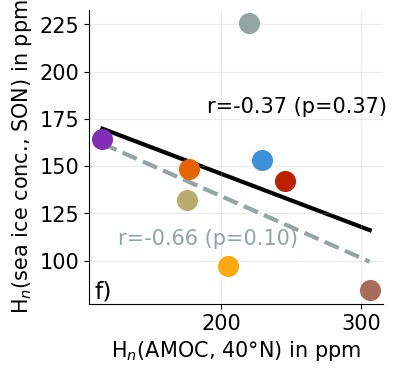

In [19]:
fig,ax = _make_correlation_plot(run_params,
                        'AMOC_40N',r'AMOC, 40°N','Sv',region_of_choice,'normalized_hysteresis_area',
                        'siconc_son_means',r'sea ice conc., SON','-',region_of_choice,'normalized_hysteresis_area',
                         panellabel = 'f)',                                      
                         panellabelloc = [0.02,0.02],
                         correlation_loc = [0.4,0.65],
                         include_correlation_under_exclusion_of='CNRM-ESM2-1',
                         correlation_loc2 = [0.1,0.2])
if savefigs == True:
    fig.savefig(f'{plot_dir}/correlation_plot_HnAMOC_vs_HnSICONC.png',dpi=300,transparent=True)



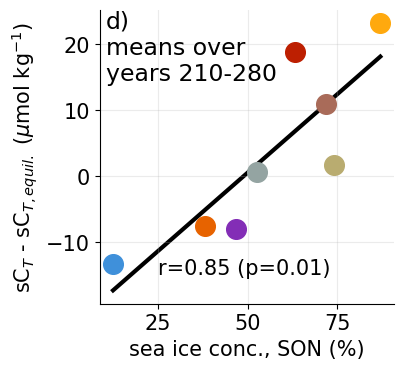

In [20]:
fig,ax = _make_correlation_plot(run_params,
                        'siconc_son_means',r'sea ice conc., SON','%',region_of_choice,'rampdown_means_2nd_half',
                        'sCT_disequilibrium',r'sC$_T$ - sC$_{T,equil.}$',r'$\mu$mol kg$^{-1}$',region_of_choice,'rampdown_means_2nd_half',
                         panellabel = 'd)\nmeans over\nyears 210-280',                                      
                         panellabelloc = [0.02,0.76],
                         correlation_loc = [0.2,0.1])
if savefigs == True:
    fig.savefig(f'{plot_dir}/correlation_plot_SICONCmean_vs_sCTmean.png',dpi=300,transparent=True)



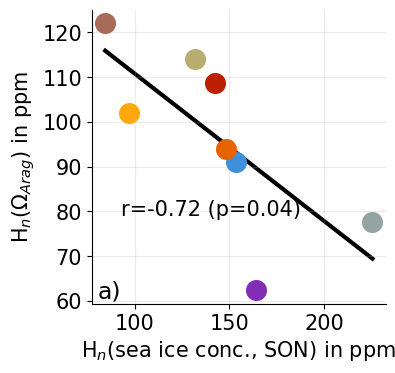

In [21]:
fig,ax = _make_correlation_plot(run_params,
                        'siconc_son_means',r'sea ice conc., SON','-',region_of_choice,'normalized_hysteresis_area',
                        'omegaa',r'$\Omega_{Arag}$','-',region_of_choice,'normalized_hysteresis_area',
                         panellabel = 'a)',                                      
                         panellabelloc = [0.02,0.02],
                         correlation_loc = [0.1,0.3])
if savefigs == True:
    fig.savefig(f'{plot_dir}/correlation_plot_HnSICONC_vs_HnOmegaa.png',dpi=300,transparent=True)


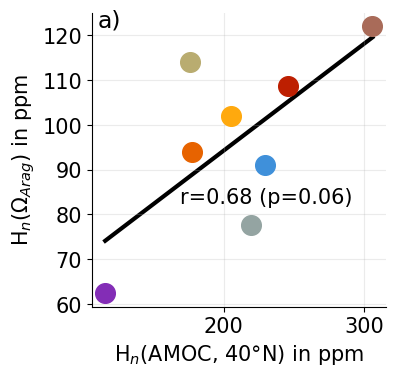

In [22]:
fig,ax = _make_correlation_plot(run_params,
                        'AMOC_40N',r'AMOC, 40°N','Sv',region_of_choice,'normalized_hysteresis_area',
                        'omegaa',r'$\Omega_{Arag}$','-',region_of_choice,'normalized_hysteresis_area',
                         panellabel = 'a)',                                      
                         panellabelloc = [0.02,0.95],
                         correlation_loc = [0.3,0.35])
if savefigs == True:
    fig.savefig(f'{plot_dir}/correlation_plot_HnAMOC_vs_HnOmegaa.png',dpi=300,transparent=True)



## Plot a legend

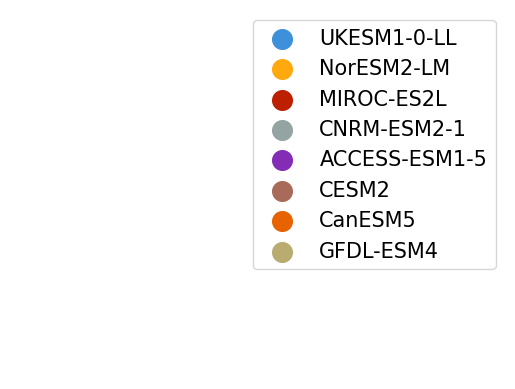

In [23]:
fig, ax = plt.subplots()
for key in run_params.keys():
    ax.scatter(0,0,200,run_params[key].runcol,label=run_params[key].model)
ax.set_xlim([10,20]);ax.set_ylim([10,20])
plt.gca().set_axis_off()
plt.legend()
if savefigs == True:
    fig.savefig(f'{plot_dir}/correlation_plot_legend.png',dpi=300,transparent=True)


# Plot the sign-aware hysteresis areas

/net/nfs/tools/u20/Python/miniconda3_py311_23.11.0-2/envs/pangeo-meso-2024.01.22/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  k, _ = kurtosistest(a, axis)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.368
Method:                 Least Squares   F-statistic:                     3.041
Date:                Thu, 11 Sep 2025   Prob (F-statistic):              0.137
Time:                        14:44:51   Log-Likelihood:                 14.428
No. Observations:                   8   AIC:                            -22.86
Df Residuals:                       5   BIC:                            -22.62
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2433      0.070     -3.487      0.0

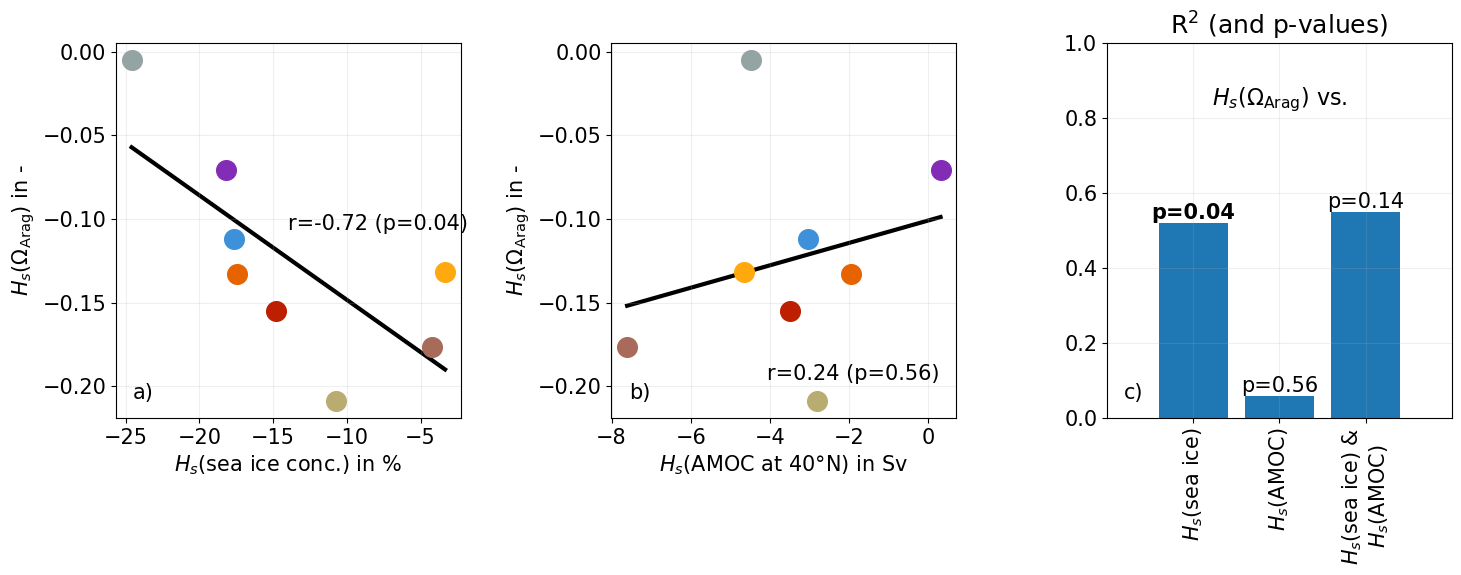

/net/nfs/tools/u20/Python/miniconda3_py311_23.11.0-2/envs/pangeo-meso-2024.01.22/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  k, _ = kurtosistest(a, axis)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     6.634
Date:                Thu, 11 Sep 2025   Prob (F-statistic):             0.0392
Time:                        14:44:52   Log-Likelihood:                -29.451
No. Observations:                   8   AIC:                             64.90
Df Residuals:                       5   BIC:                             65.14
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         96.7707     29.050      3.331      0.0

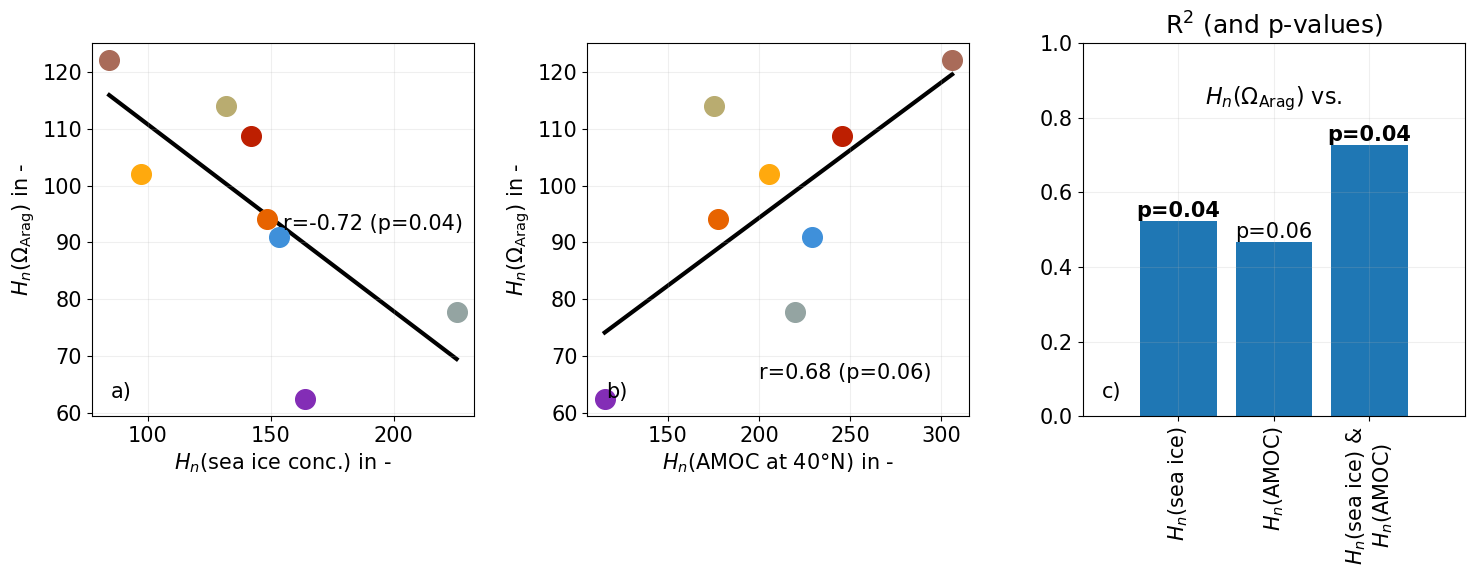

/net/nfs/tools/u20/Python/miniconda3_py311_23.11.0-2/envs/pangeo-meso-2024.01.22/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  k, _ = kurtosistest(a, axis)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     2.218
Date:                Thu, 11 Sep 2025   Prob (F-statistic):              0.204
Time:                        14:44:53   Log-Likelihood:                -5.3098
No. Observations:                   8   AIC:                             16.62
Df Residuals:                       5   BIC:                             16.86
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6031      0.822      3.165      0.0

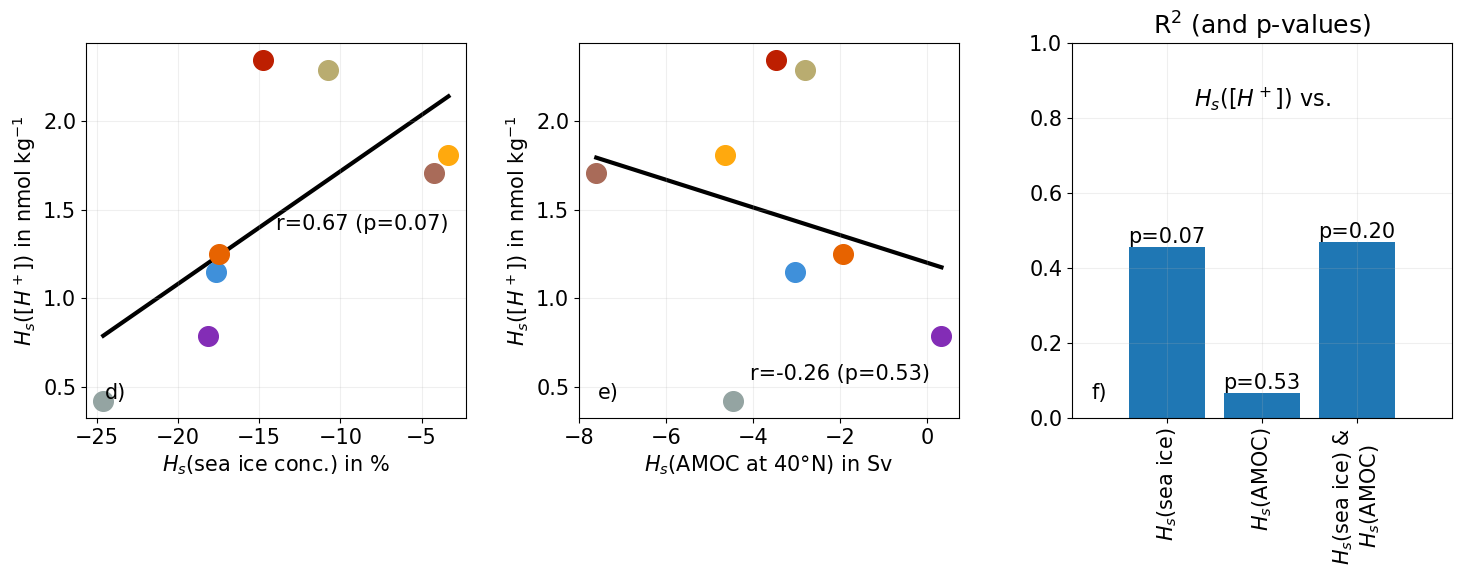

/net/nfs/tools/u20/Python/miniconda3_py311_23.11.0-2/envs/pangeo-meso-2024.01.22/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  k, _ = kurtosistest(a, axis)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     2.211
Date:                Thu, 11 Sep 2025   Prob (F-statistic):              0.205
Time:                        14:44:55   Log-Likelihood:                -33.884
No. Observations:                   8   AIC:                             73.77
Df Residuals:                       5   BIC:                             74.01
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        115.9211     50.562      2.293      0.0

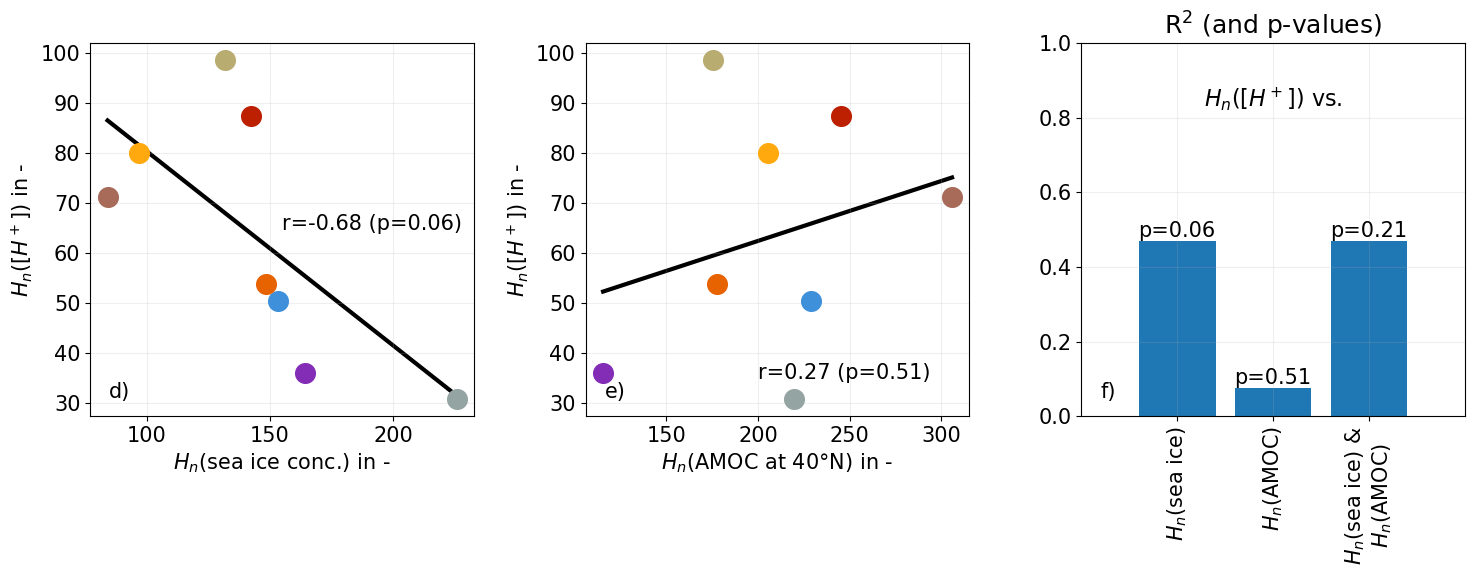

In [40]:
carbonate_var = 'hplus' # 'omegaa'
hysteresis_type = 'signed_hysteresis_area' #'normalized_hysteresis_area' # ,'signed_hysteresis_area'
for carbonate_var in ['omegaa','hplus']:
    if carbonate_var == 'omegaa':
        plotlabels = ['a)','b)','c)']
    elif carbonate_var == 'hplus':
        plotlabels = ['d)','e)','f)']
    for hysteresis_type in ['signed_hysteresis_area','normalized_hysteresis_area']:
        
        if carbonate_var == 'omegaa':
            label_string = r'$\Omega_\text{Arag}$'
            unit = '-'
        elif carbonate_var == 'hplus':
            label_string = r'$[H^+]$'
            unit = r'nmol kg$^{-1}$'
        
        if hysteresis_type == 'normalized_hysteresis_area':
            hyst_string = r'$H_n$'
            unit = '-'
        elif hysteresis_type == 'signed_hysteresis_area':
            hyst_string = r'$H_s$'
        
        fig, ax = plt.subplots(1,3,figsize=(15,6))
        
        # ax[0]: Hs(Omega) vs. Hs(sea ice)
        ds_x = _get_dataset('siconc_son_means','central Arctic',hysteresis_type) # ,'signed_hysteresis_area')
        ds_y = _get_dataset(carbonate_var,'central Arctic',hysteresis_type) # ,'signed_hysteresis_area')
        xvals0 = []
        yvals0 = []
        for key in run_params.keys():
            ax[0].scatter(ds_x[key],ds_y[key],200,run_params[key].runcol,zorder=2,label=run_params[key].model)#,colors=
            xvals0.append(ds_x[key].values)
            yvals0.append(ds_y[key].values)
        # include the correlation line
        slope0, intercept0, r_value0, p_value0, std_err0 = spstats.linregress(xvals0, yvals0)
        ax[0].plot(np.sort(xvals0),intercept0+np.sort(xvals0)*slope0,color='k',linewidth=3,zorder=1)
        # add text
        panellabelloc=[0.05,0.05]
        xpos,ypos = panellabelloc
        ax[0].text(xpos,ypos,plotlabels[0],transform=ax[0].transAxes)#,fontsize=fontsize+2)
        correlation_loc=[0.5,0.5]
        xpos,ypos = correlation_loc
        ax[0].text(xpos,ypos,f'r={r_value0:.2f} (p={p_value0:.2f})',transform=ax[0].transAxes)
        if hysteresis_type == 'signed_hysteresis_area':
            ax[0].set_xlabel(f'{hyst_string}'+'(sea ice conc.) in %')
        else:
            ax[0].set_xlabel(f'{hyst_string}(sea ice conc.) in -')
        ax[0].set_ylabel(f'{hyst_string}'+f'({label_string}) in {unit}')
        ax[0].grid(alpha=0.2)
        
        # ax[1]: Hs(Omega) vs. Hs(AMOC)
        ds_x = _get_dataset('AMOC_40N','',hysteresis_type) # ,'signed_hysteresis_area')
        ds_y = _get_dataset(carbonate_var,'central Arctic',hysteresis_type) # ,'signed_hysteresis_area')
        xvals1 = []
        yvals1 = []
        for key in run_params.keys():
            ax[1].scatter(ds_x[key],ds_y[key],200,run_params[key].runcol,zorder=2,label=run_params[key].model)#,colors=
            xvals1.append(ds_x[key].values)
            yvals1.append(ds_y[key].values)
        # include the correlation line
        slope1, intercept1, r_value1, p_value1, std_err1 = spstats.linregress(xvals1, yvals1)
        ax[1].plot(np.sort(xvals1),intercept1+np.sort(xvals1)*slope1,color='k',linewidth=3,zorder=1)
        # add text
        panellabelloc=[0.05,0.05]
        xpos,ypos = panellabelloc
        ax[1].text(xpos,ypos,plotlabels[1],transform=ax[1].transAxes)#,fontsize=fontsize+2)
        correlation_loc=[0.45,0.1]
        xpos,ypos = correlation_loc
        ax[1].text(xpos,ypos,f'r={r_value1:.2f} (p={p_value1:.2f})',transform=ax[1].transAxes)
        if hysteresis_type == 'signed_hysteresis_area':
            ax[1].set_xlabel(f'{hyst_string}'+'(AMOC at 40°N) in Sv')
        else:
            ax[1].set_xlabel(f'{hyst_string}'+'(AMOC at 40°N) in -')
        ax[1].set_ylabel(f'{hyst_string}'+f'({label_string}) in {unit}')
        ax[1].grid(alpha=0.2)
        
        
        # calculate a multilinear regression using both sea ice and AMOC as predictors
        joint_xvals = np.stack([xvals0, xvals1], axis=0).T
        import statsmodels.api as sm
        X = sm.add_constant(joint_xvals)
        model = sm.OLS(yvals1, X).fit()
        # Print summary
        print(model.summary())
        
        
        # add the bar plot
        rvalues = [r_value0**2,r_value1**2,model.rsquared]
        pvalues = [p_value0,p_value1,model.f_pvalue]
        barxs = [1,2,3]
        xlabels = [f'{hyst_string}'+'(sea ice)',
                   f'{hyst_string}'+'(AMOC)',
                   f'{hyst_string}'+'(sea ice) &'+'\n'+f'{hyst_string}(AMOC)']
        # Format labels and font weights
        labels = ['p=%.2f' % val for val in pvalues]
        fontweights = ['bold' if val < 0.05 else 'normal' for val in pvalues]
        # Bar plot
        bars = ax[2].bar(barxs, rvalues)
        # Manually add labels with individual fontweights
        for bar, label, weight in zip(bars, labels, fontweights):
            height = bar.get_height()
            va = 'bottom' if height >= 0 else 'top'
            offset = 3 if height >= 0 else -5  # tweak this if needed
            ax[2].text(
                bar.get_x() + bar.get_width() / 2,
                height,
                label,
                ha='center',
                va=va,
                fontweight=weight,
                color='black'
            )
        # Styling
        ax[2].text(0.5,0.85,f'{hyst_string}'+f'({label_string}) vs.',ha='center',va='center',transform=ax[2].transAxes,fontsize=16)
        ax[2].set_ylim([0, 1])
        ax[2].set_xlim([0, 4])
        ax[2].set_xticks(barxs)
        ax[2].set_xticklabels(xlabels,rotation=90,ha='center')
        ax[2].set_title(r'R$^2$ (and p-values)')
        ax[2].grid(alpha=0.2)
        xpos,ypos = panellabelloc
        ax[2].text(xpos,ypos,plotlabels[2],transform=ax[2].transAxes)#,fontsize=fontsize+2)
        plt.tight_layout()
        if savefigs == True:
            fig.savefig(f"{plot_dir}/correlation_plots_{'central Arctic'}_{carbonate_var}_{hysteresis_type}.png",dpi=300,transparent=True)
        plt.show()